In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))
from src.utils.config import METRICS_DIR
from src.visualization.plot_config import apply_plot_style

apply_plot_style()

dip = pd.read_csv(os.path.join(METRICS_DIR, "dip_by_word_year.csv"))
print(dip.shape, dip["word"].nunique(), "words")
dip.head()

(198195, 6) 5891 words


,word,year,n_usages,dip,p_value,tested
0,abandon,1990,2,NaN,NaN,False
1,abandon,1991,3,NaN,NaN,False
2,abandon,1992,9,NaN,NaN,False
3,abandon,1993,5,NaN,NaN,False
4,abandon,1994,5,NaN,NaN,False


## 1. Marginal distributions

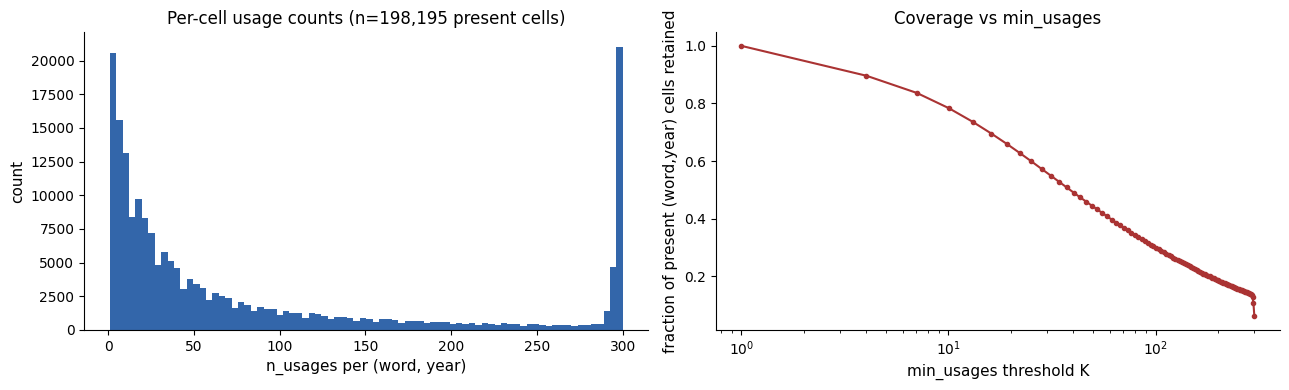

In [2]:
# n_usages per (word, year) -- histogram on log-x, and cumulative coverage
present = dip[dip["n_usages"] > 0].copy()
tested = dip[dip["tested"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(present["n_usages"], bins=80, color="#3366AA")
axes[0].set_xlabel("n_usages per (word, year)")
axes[0].set_ylabel("count")
axes[0].set_title(f"Per-cell usage counts (n={len(present):,} present cells)")

ks = np.linspace(1, present["n_usages"].max(), 100)
frac_cells = [(present["n_usages"] >= k).mean() for k in ks]
axes[1].plot(ks, frac_cells, "o-", markersize=3, color="#AA3333")
axes[1].set_xscale("log")
axes[1].set_xlabel("min_usages threshold K")
axes[1].set_ylabel("fraction of present (word,year) cells retained")
axes[1].set_title("Coverage vs min_usages")

fig.tight_layout()
plt.show()

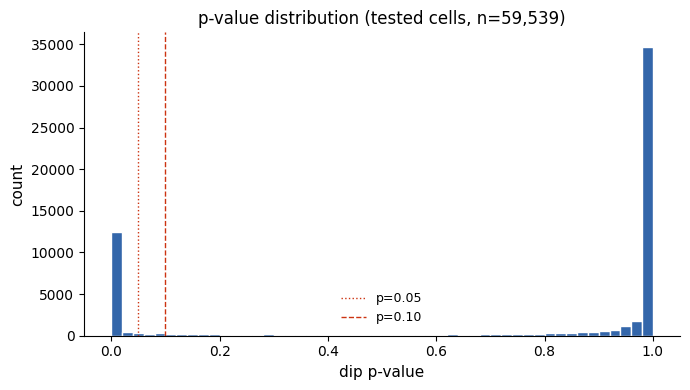

In [3]:
# p_value histogram (tested cells only) -- uniform under unimodal null,
# spike near 0 under multimodal.
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(tested["p_value"], bins=50, color="#3366AA", edgecolor="white")
ax.axvline(0.05, color="#CC3311", ls=":", lw=1, label="p=0.05")
ax.axvline(0.10, color="#CC3311", ls="--", lw=1, label="p=0.10")
ax.set_xlabel("dip p-value")
ax.set_ylabel("count")
ax.set_title(f"p-value distribution (tested cells, n={len(tested):,})")
ax.legend()
fig.tight_layout()
plt.show()

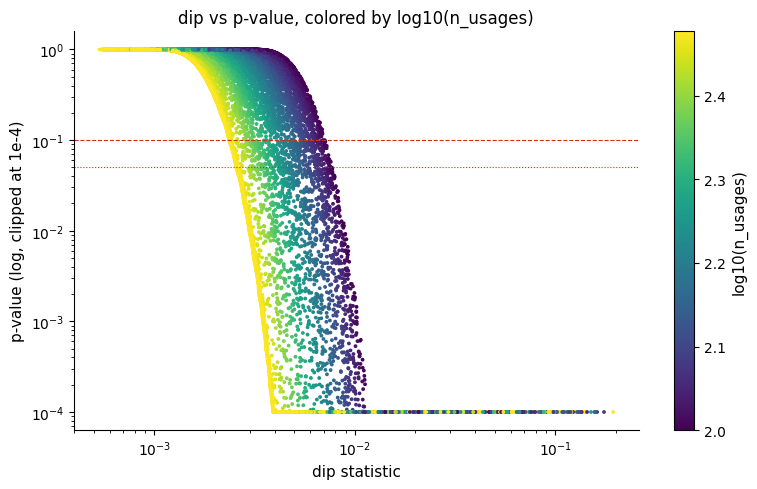

In [4]:
# dip vs p_value, colored by n_usages -- shows how null shrinks with n.
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    tested["dip"],
    tested["p_value"].clip(lower=1e-4),
    c=np.log10(tested["n_usages"]),
    s=3, alpha=1, cmap="viridis",
)
ax.set_yscale("log")
ax.set_xlabel("dip statistic")
ax.set_ylabel("p-value (log, clipped at 1e-4)")
ax.set_title("dip vs p-value, colored by log10(n_usages)")
cb = plt.colorbar(sc, ax=ax)
cb.set_label("log10(n_usages)")
for ref, ls in [(0.05, ":"), (0.1, "--")]:
    ax.axhline(ref, color="#CC3311", ls=ls, lw=0.8)
ax.set_xscale('log')
fig.tight_layout()
plt.show()

## 2. Within-word behaviour across time

Raw spaghetti: one thin line per word across years, for `p_value`, `dip`, and `n_usages`.
Then per-word spread (`max - min`, `std`) against mean `n_usages` to see the noise funnel.

In [5]:
# Build sorted per-word series (tested cells only) once, reuse below.
tested_sorted = tested.sort_values(["word", "year"])
groups = tested_sorted.groupby("word", sort=False)
# Restrict to words with a reasonable number of tested years so lines are meaningful.
min_years_for_line = 5
word_sizes = groups.size()
line_words = word_sizes[word_sizes >= min_years_for_line].index
print(f"{len(line_words)} words with >= {min_years_for_line} tested years "
      f"(of {len(word_sizes)} words with any tested year)")

2790 words with >= 5 tested years (of 3964 words with any tested year)


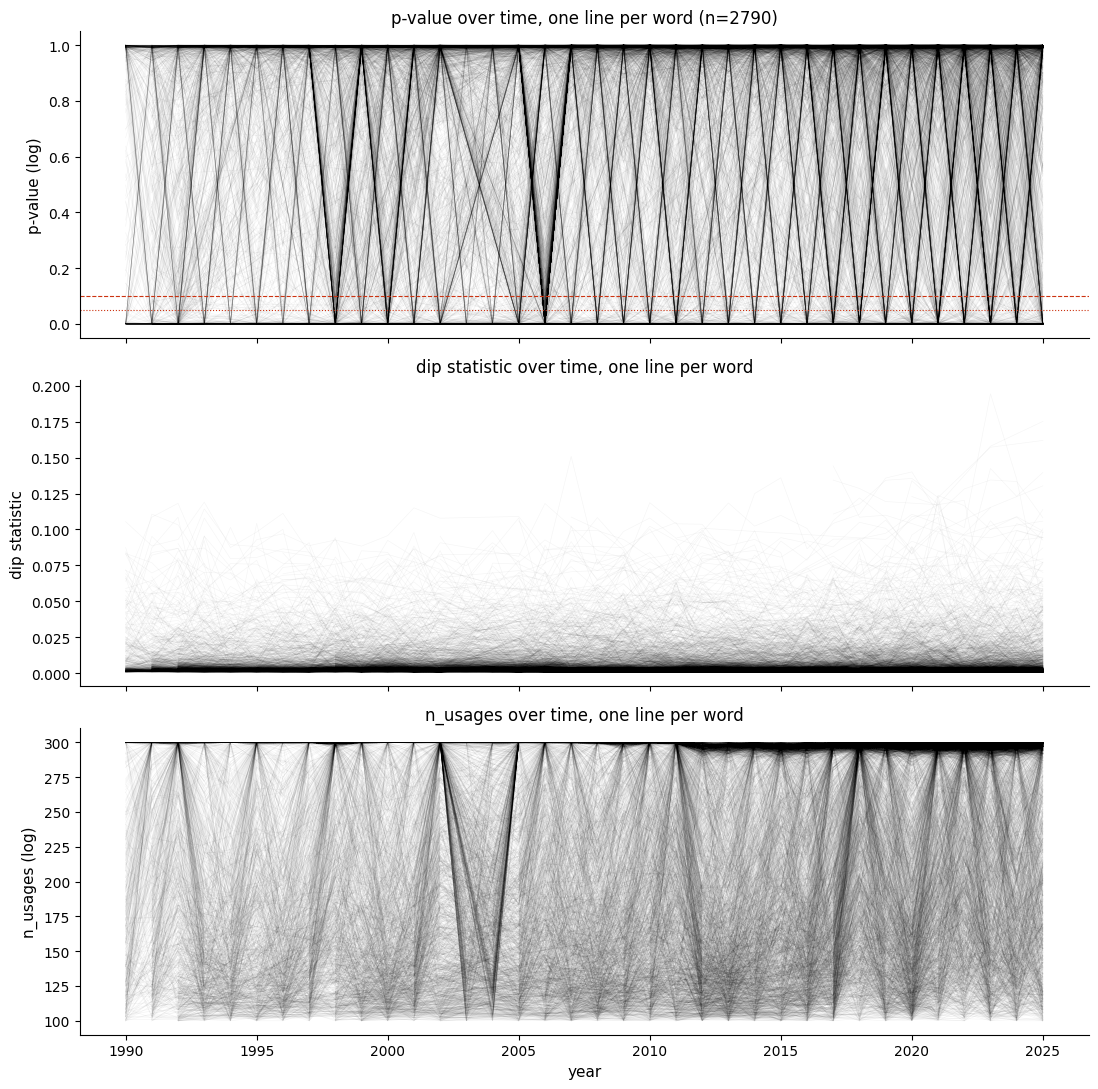

In [6]:
# Spaghetti plots: one thin line per word, tested cells only.
fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=True)

for word in line_words:
    g = groups.get_group(word)
    axes[0].plot(g["year"], g["p_value"].clip(lower=1e-4),
                 color="black", alpha=0.04, lw=0.5)
    axes[1].plot(g["year"], g["dip"],
                 color="black", alpha=0.04, lw=0.5)
    axes[2].plot(g["year"], g["n_usages"],
                 color="black", alpha=0.04, lw=0.5)

#axes[0].set_yscale("log")
axes[0].axhline(0.05, color="#CC3311", ls=":", lw=0.8)
axes[0].axhline(0.10, color="#CC3311", ls="--", lw=0.8)
axes[0].set_ylabel("p-value (log)")
axes[0].set_title(f"p-value over time, one line per word (n={len(line_words)})")

axes[1].set_ylabel("dip statistic")
axes[1].set_title("dip statistic over time, one line per word")

#axes[2].set_yscale("log")
axes[2].set_ylabel("n_usages (log)")
axes[2].set_xlabel("year")
axes[2].set_title("n_usages over time, one line per word")

fig.tight_layout()
plt.show()

In [7]:
# Per-word summaries: spread of p/dip vs mean n_usages -> the noise funnel.
per_word = groups.agg(
    n_years_tested=("year", "size"),
    mean_n=("n_usages", "mean"),
    median_n=("n_usages", "median"),
    std_logp=("p_value", lambda s: np.log10(s.clip(lower=1e-4)).std()),
    range_logp=("p_value", lambda s: np.log10(s.clip(lower=1e-4)).max()
                 - np.log10(s.clip(lower=1e-4)).min()),
    std_dip=("dip", "std"),
    range_dip=("dip", lambda s: s.max() - s.min()),
    min_p=("p_value", "min"),
    max_p=("p_value", "max"),
).reset_index()
per_word = per_word[per_word["n_years_tested"] >= min_years_for_line]
print(per_word.shape)
per_word.describe()

(2790, 10)


,n_years_tested,mean_n,median_n,std_logp,range_logp,std_dip,range_dip,min_p,max_p
count,2790.000000,2790.000000,2790.000000,2790.000000,2790.000000,2790.000000,2790.000000,2790.000000,2790.000000
mean,20.510394,209.728387,215.555556,0.754258,2.293923,0.003956,0.014053,0.198682,0.936270
std,10.287673,53.805237,68.342422,0.665623,1.721292,0.005678,0.018822,0.326193,0.230302
min,5.000000,105.333333,102.000000,0.000000,0.000000,0.000111,0.000432,0.000000,0.000000
25%,11.000000,162.744048,151.000000,0.096849,0.366634,0.000816,0.002917,0.000000,0.998846
50%,21.000000,211.260989,208.000000,0.674312,2.786656,0.001573,0.005903,0.000070,1.000000
75%,30.000000,257.798529,295.500000,1.350053,4.000000,0.004639,0.016958,0.291129,1.000000
max,36.000000,299.794118,300.000000,2.189808,4.000000,0.063015,0.180004,0.994680,1.000000


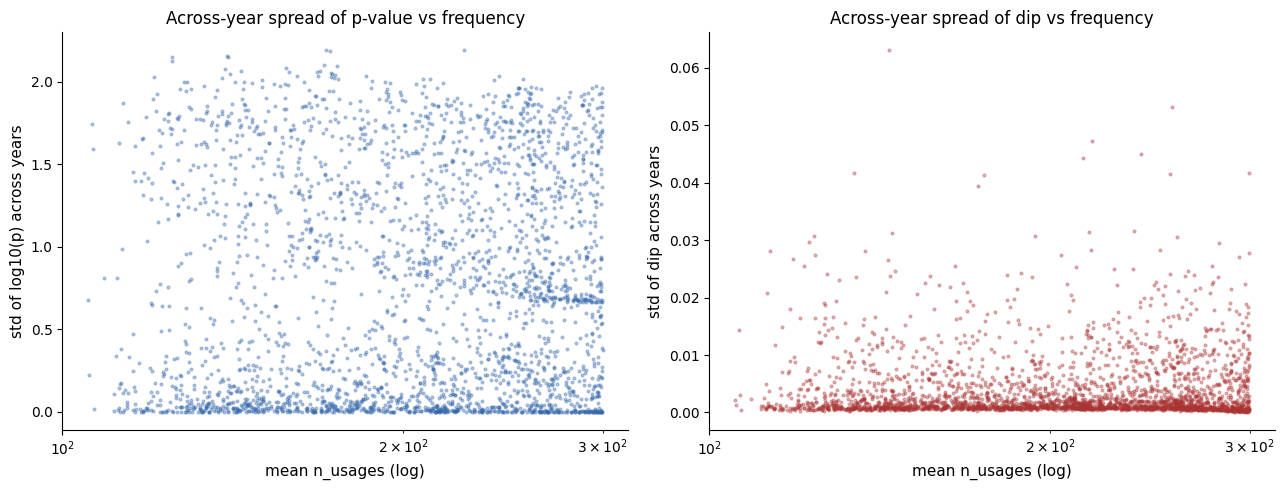

In [8]:
# Noise funnels: per-word spread of p and dip versus mean n_usages.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(per_word["mean_n"], per_word["std_logp"],
                s=4, alpha=0.35, color="#3366AA")
axes[0].set_xscale("log")
axes[0].set_xlabel("mean n_usages (log)")
axes[0].set_ylabel("std of log10(p) across years")
axes[0].set_title("Across-year spread of p-value vs frequency")

axes[1].scatter(per_word["mean_n"], per_word["std_dip"],
                s=4, alpha=0.35, color="#AA3333")
axes[1].set_xscale("log")
axes[1].set_xlabel("mean n_usages (log)")
axes[1].set_ylabel("std of dip across years")
axes[1].set_title("Across-year spread of dip vs frequency")

fig.tight_layout()
plt.show()

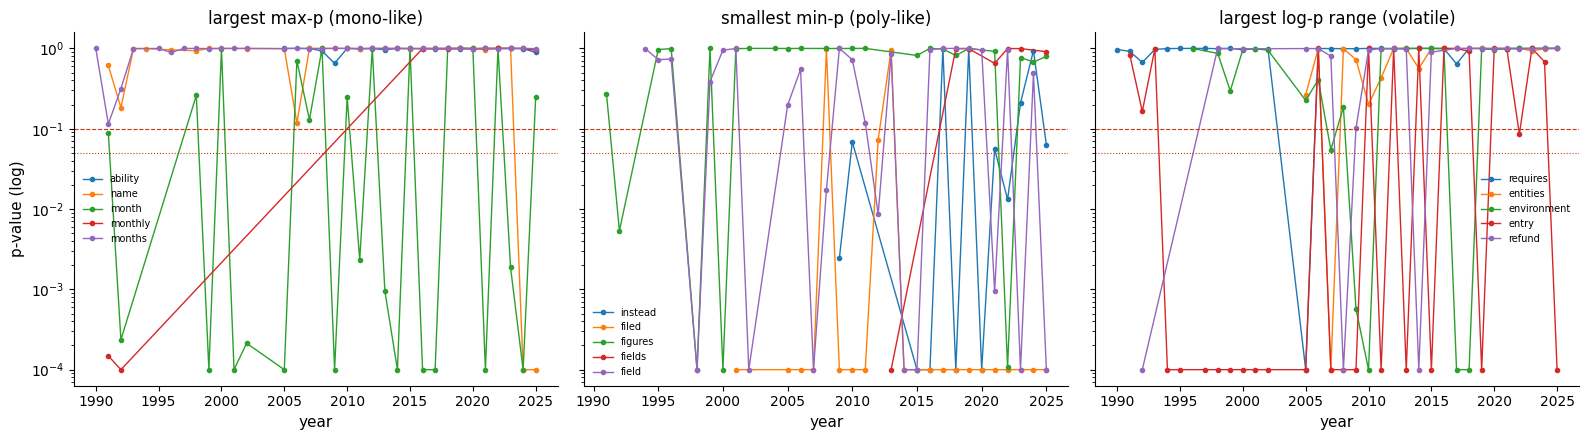

In [9]:
# Pick out a few archetypes to eyeball: stable-high-p, stable-low-p, volatile.
stable_mono = per_word.sort_values("max_p", ascending=False).head(5)["word"].tolist()
stable_poly = per_word.sort_values("min_p").head(5)["word"].tolist()
volatile = per_word.sort_values("range_logp", ascending=False).head(5)["word"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, title, words in [
    (axes[0], "largest max-p (mono-like)", stable_mono),
    (axes[1], "smallest min-p (poly-like)", stable_poly),
    (axes[2], "largest log-p range (volatile)", volatile),
]:
    for w in words:
        g = groups.get_group(w)
        ax.plot(g["year"], g["p_value"].clip(lower=1e-4),
                "o-", markersize=3, lw=1, label=w)
    ax.set_yscale("log")
    ax.axhline(0.05, color="#CC3311", ls=":", lw=0.8)
    ax.axhline(0.10, color="#CC3311", ls="--", lw=0.8)
    ax.set_xlabel("year")
    ax.set_title(title)
    ax.legend(fontsize=7, loc="best")
axes[0].set_ylabel("p-value (log)")

fig.tight_layout()
plt.show()

## 3. Candidate classifier

A year is **evaluable** iff `n_usages >= N_FLOOR`.
A year **passes** iff evaluable AND `p > P_THRESHOLD` AND `dip < DIP_CEILING`.
A year **fails** iff evaluable AND not passing.
A word is **monosemous** iff `n_pass >= K_PASS` AND `n_fail <= MAX_FAILS`.

`MAX_FAILS` defaults to 0 (strict) but is configurable. Goal: see what each knob does, so we can later drop those that don't matter.

In [21]:
def classify(df, n_floor, p_threshold, dip_ceiling, k_pass, max_fails=0):
    """Return per-word dataframe with pass/fail counts and is_monosemous flag.

    df: the raw dip_by_word_year frame.
    """
    d = df.copy()
    d["evaluable"] = d["n_usages"] >= n_floor
    d["passes"] = (
        d["evaluable"]
        & (d["p_value"] > p_threshold)
        & (d["dip"] < dip_ceiling)
    )
    d["fails"] = d["evaluable"] & ~d["passes"]

    per = d.groupby("word").agg(
        n_years_present=("n_usages", lambda s: int((s > 0).sum())),
        n_evaluable=("evaluable", "sum"),
        n_pass=("passes", "sum"),
        n_fail=("fails", "sum"),
        mean_n_eval=("n_usages", lambda s: s[s >= n_floor].mean()),
    ).reset_index()
    per["is_monosemous"] = (
        (per["n_pass"] >= k_pass) & (per["n_fail"] <= max_fails)
    )
    return per


# Starting point. These are our knobs to explore.
N_FLOOR = 150
P_THRESHOLD = 0.10
DIP_CEILING = 0.02
K_PASS = 5
MAX_FAILS = 0

result = classify(dip, N_FLOOR, P_THRESHOLD, DIP_CEILING, K_PASS, MAX_FAILS)
n_total = len(result)
n_mono = int(result["is_monosemous"].sum())
print(f"{n_mono} / {n_total} words classified monosemous "
      f"(N_FLOOR={N_FLOOR}, p>{P_THRESHOLD}, dip<{DIP_CEILING}, "
      f"K_PASS={K_PASS}, MAX_FAILS={MAX_FAILS})")
result.sort_values("n_pass", ascending=False).head(15)

773 / 5891 words classified monosemous (N_FLOOR=150, p>0.1, dip<0.02, K_PASS=5, MAX_FAILS=0)


,word,n_years_present,n_evaluable,n_pass,n_fail,mean_n_eval,is_monosemous
1794,documents,36,36,36,0,296.250000,True
399,article,36,36,36,0,298.638889,True
4290,purpose,36,36,36,0,294.972222,True
4747,right,36,36,36,0,293.444444,True
4920,service,36,36,36,0,290.805556,True
5335,take,36,36,36,0,294.694444,True
5336,taken,36,36,36,0,295.472222,True
2593,having,36,36,36,0,295.000000,True
2854,information,36,36,36,0,296.611111,True
820,certain,36,36,36,0,297.722222,True


In [ ]:
# One-knob-at-a-time sensitivity: vary one parameter, hold the rest at defaults,
# and report the size of the resulting monosemous set.
defaults = dict(
    n_floor=N_FLOOR, p_threshold=P_THRESHOLD, dip_ceiling=DIP_CEILING,
    k_pass=K_PASS, max_fails=MAX_FAILS,
)
sweeps = {
    "n_floor":     [100, 125, 150, 175, 200, 250],
    "p_threshold": [0.01, 0.05, 0.10, 0.20, 0.30],
    "dip_ceiling": [0.005, 0.01, 0.02, 0.05, 0.10, 1.0],  # 1.0 == no ceiling
    "k_pass":      [3, 5, 8, 10, 15],
    "max_fails":   [0, 1, 2, 3, 5],
}

fig, axes = plt.subplots(1, len(sweeps), figsize=(14, 2.5), sharey=True)
for ax, (param, values) in zip(axes, sweeps.items()):
    counts = []
    for v in values:
        kwargs = {**defaults, param: v}
        r = classify(dip, **kwargs)
        counts.append(int(r["is_monosemous"].sum()))
    ax.plot(values, counts, "o-", color="#3366AA")
    ax.axvline(defaults[param], color="#CC3311", ls=":", lw=0.8)
    ax.set_xlabel(param)
    ax.set_ylabel("# monosemous")
    ax.set_title(param)
    if param in set(["dip_ceiling"]):
        ax.set_xscale("log")
fig.suptitle("Sensitivity: each knob swept with others held at defaults")
fig.tight_layout()
plt.show()

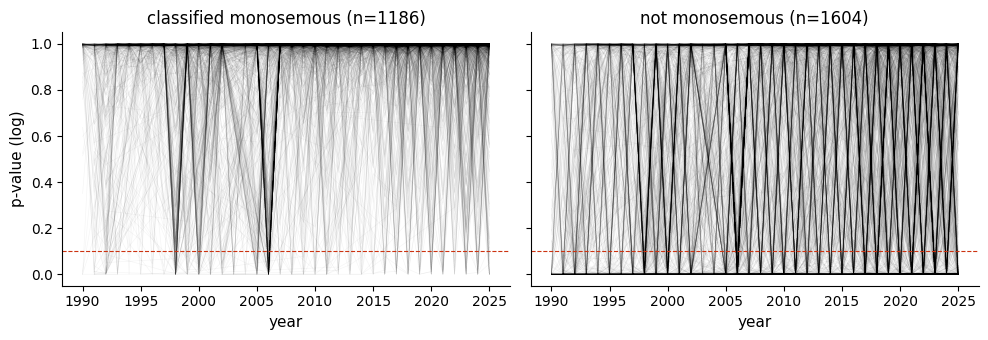

In [ ]:
# Eyeball the classified set: spaghetti of p-value over years, colored by class.
mono_set = set(result.loc[result["is_monosemous"], "word"])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

for word in line_words:
    g = groups.get_group(word)
    ax = axes[0] if word in mono_set else axes[1]
    ax.plot(g["year"], g["p_value"].clip(lower=1e-4),
            color="black", alpha=0.04, lw=0.5)

for ax, title, count in [
    (axes[0], "classified monosemous", len(mono_set & set(line_words))),
    (axes[1], "not monosemous", len(set(line_words) - mono_set)),
]:
    ax.axhline(P_THRESHOLD, color="#CC3311", ls="--", lw=0.8)
    #ax.set_yscale("log")
    ax.set_xlabel("year")
    ax.set_title(f"{title} (n={count})")
axes[0].set_ylabel("p-value (log)")
fig.tight_layout()
plt.show()